In [13]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers[1].csv to Mall_Customers[1] (3).csv


Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Cluster Probabilities (First 5 Rows):
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]

=== GMM RESULTS ===
Silhouette Score: 0.5536892843811245
Log Likelihood: -2.262502621973241
AIC: 963.0010487892964
B

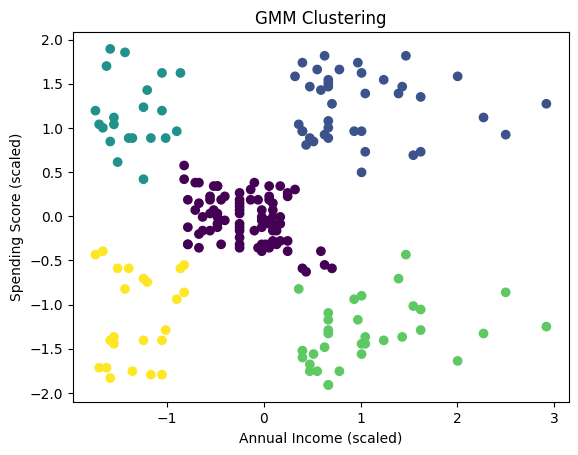


=== COMPARISON ===
K-Means Silhouette: 0.5546571631111091
GMM Silhouette: 0.5536892843811245
K-Means performs better (simpler structure).


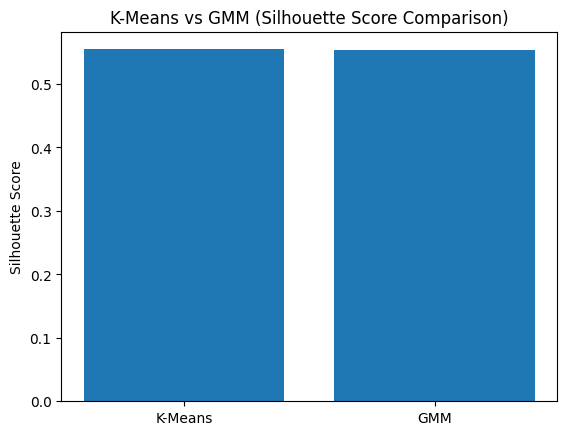


Comparison Values:
K-Means Silhouette: 0.5546571631111091
GMM Silhouette: 0.5536892843811245


In [19]:
# ==============================
# STEP 2: IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==============================
# STEP 3: LOAD DATASET
# ==============================
df = pd.read_csv("Mall_Customers[1].csv")

print("Dataset Preview:")
print(df.head())

# ==============================
# STEP 4: SELECT FEATURES
# ==============================
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# ==============================
# STEP 5: PREPROCESSING (SCALING)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# STEP 6: APPLY GMM (EM)
# ==============================
optimal_k = 5

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm.fit(X_scaled)

labels_gmm = gmm.predict(X_scaled)

# ==============================
# STEP 7: PROBABILITIES
# ==============================
probabilities = gmm.predict_proba(X_scaled)

print("\nCluster Probabilities (First 5 Rows):")
print(probabilities[:5])

# ==============================
# STEP 8: EVALUATION METRICS
# ==============================
silhouette_gmm = silhouette_score(X_scaled, labels_gmm)
log_likelihood = gmm.score(X_scaled)
aic = gmm.aic(X_scaled)
bic = gmm.bic(X_scaled)

print("\n=== GMM RESULTS ===")
print("Silhouette Score:", silhouette_gmm)
print("Log Likelihood:", log_likelihood)
print("AIC:", aic)
print("BIC:", bic)

# ==============================
# STEP 9: VISUALIZATION
# ==============================
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_gmm)
plt.title("GMM Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# ==============================
# STEP 10: COMPARISON
# ==============================
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans)

print("\n=== COMPARISON ===")
print("K-Means Silhouette:", silhouette_kmeans)
print("GMM Silhouette:", silhouette_gmm)

if silhouette_gmm > silhouette_kmeans:
    print("GMM performs better (captures complex distributions).")
else:
    print("K-Means performs better (simpler structure).")

# ==============================
# ADDED: BAR CHART
# ==============================
models = ['K-Means', 'GMM']
scores = [silhouette_kmeans, silhouette_gmm]

plt.figure()
plt.bar(models, scores)
plt.title("K-Means vs GMM (Silhouette Score Comparison)")
plt.ylabel("Silhouette Score")
plt.show()

print("\nComparison Values:")
print("K-Means Silhouette:", silhouette_kmeans)
print("GMM Silhouette:", silhouette_gmm)